# MacroChefAI – End-to-End MVP Notebook

This notebook lets you run and inspect the full MVP pipeline in one place:

- raw data loading and preprocessing
- feature engineering
- healthy vs unhealthy classification
- optional cook-time regression
- KNN macro-based recommendation
- TF-IDF ingredient matching
- final ranking logic

Run this notebook from the project root so paths like `data/raw/recipes.csv` work correctly.


In [23]:
import os
import ast
import json
import re
import joblib
from pathlib import Path

import numpy as np
import pandas as pd

from scipy.sparse import save_npz
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, mean_absolute_error, r2_score
from sklearn.neighbors import NearestNeighbors
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import RandomForestRegressor

EPS = 1e-6

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

RAW_DATA_PATH = "raw_data/recipes.csv"
PROCESSED_DATA_PATH = "processed_data/dataset.parquet"

KNN_MODEL_PATH = "models/knn_macro.joblib"
TFIDF_PATH = "models/tfidf_vectorizer.joblib"
INGREDIENT_MATRIX_PATH = "models/ingredient_matrix.npz"
HEALTH_MODEL_PATH = "models/healthy_classifier.joblib"
WEIGHT_LOSS_MODEL_PATH = Path("models/weight_loss_pipeline.joblib")
WEIGHT_LOSS_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

os.makedirs("data/processed", exist_ok=True)
os.makedirs("models", exist_ok=True)

print("Notebook ready.")


Notebook ready.


In [2]:
df = pd.read_csv(RAW_DATA_PATH)
df

,RecipeId,Name,AuthorId,AuthorName,CookTime,PrepTime,TotalTime,DatePublished,Description,Images,...,SaturatedFatContent,CholesterolContent,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent,RecipeServings,RecipeYield,RecipeInstructions
0,38,Low-Fat Berry Blue Frozen Dessert,1533,Dancer,PT24H,PT45M,PT24H45M,1999-08-09T21:46:00Z,Make and share this Low-Fat Berry Blue Frozen ...,"c(""https://img.sndimg.com/food/image/upload/w_...",...,1.3,8.0,29.8,37.1,3.6,30.2,3.2,4.0,NaN,"c(""Toss 2 cups berries with sugar."", ""Let stan..."
1,39,Biryani,1567,elly9812,PT25M,PT4H,PT4H25M,1999-08-29T13:12:00Z,Make and share this Biryani recipe from Food.com.,"c(""https://img.sndimg.com/food/image/upload/w_...",...,16.6,372.8,368.4,84.4,9.0,20.4,63.4,6.0,NaN,"c(""Soak saffron in warm milk for 5 minutes and..."
2,40,Best Lemonade,1566,Stephen Little,PT5M,PT30M,PT35M,1999-09-05T19:52:00Z,This is from one of my first Good House Keepi...,"c(""https://img.sndimg.com/food/image/upload/w_...",...,0.0,0.0,1.8,81.5,0.4,77.2,0.3,4.0,NaN,"c(""Into a 1 quart Jar with tight fitting lid, ..."
3,41,Carina's Tofu-Vegetable Kebabs,1586,Cyclopz,PT20M,PT24H,PT24H20M,1999-09-03T14:54:00Z,This dish is best prepared a day in advance to...,"c(""https://img.sndimg.com/food/image/upload/w_...",...,3.8,0.0,1558.6,64.2,17.3,32.1,29.3,2.0,4 kebabs,"c(""Drain the tofu, carefully squeezing out exc..."
4,42,Cabbage Soup,1538,Duckie067,PT30M,PT20M,PT50M,1999-09-19T06:19:00Z,Make and share this Cabbage Soup recipe from F...,"""https://img.sndimg.com/food/image/upload/w_55...",...,0.1,0.0,959.3,25.1,4.8,17.7,4.3,4.0,NaN,"c(""Mix everything together and bring to a boil..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
522512,541379,Meg's Fresh Ginger Gingerbread,2002090414,rdsxc,PT35M,PT1H,PT1H35M,2020-12-22T15:27:00Z,Make and share this Meg's Fresh Ginger Gingerb...,character(0),...,7.6,54.4,278.2,48.5,0.8,22.8,3.9,8.0,1 8x8 cake pan,"c(""Preheat oven to 350&deg;F Grease an 8x8 cak..."
522513,541380,Roast Prime Rib au Poivre with Mixed Peppercorns,211566,Denver cooks,PT3H,PT30M,PT3H30M,2020-12-22T15:32:00Z,"White, black, green, and pink peppercorns add ...","""https://img.sndimg.com/food/image/upload/w_55...",...,71.4,433.8,766.3,3.2,0.7,0.1,117.0,8.0,1 Roast,"c(""Position rack in center of oven and preheat..."
522514,541381,Kirshwasser Ice Cream,2001131545,Jonathan F.,PT3H,PT1H,PT4H,2020-12-22T15:33:00Z,Make and share this Kirshwasser Ice Cream reci...,character(0),...,72.6,470.9,192.5,33.9,0.0,17.3,12.8,6.0,NaN,"c(""heat half and half and heavy cream to a sim..."
522515,541382,Quick & Easy Asian Cucumber Salmon Rolls,2001004241,CLUBFOODY,NaN,PT15M,PT15M,2020-12-22T22:11:00Z,"Extremely quick and easy to make, these are gr...","""https://img.sndimg.com/food/image/upload/w_55...",...,0.1,2.9,100.5,0.3,0.0,0.1,2.4,NaN,20 rolls,"c(""In a small bowl, combine mayo and wasabi pa..."


In [3]:
df.shape

(522517, 28)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522517 entries, 0 to 522516
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   RecipeId                    522517 non-null  int64  
 1   Name                        522517 non-null  object 
 2   AuthorId                    522517 non-null  int64  
 3   AuthorName                  522517 non-null  object 
 4   CookTime                    439972 non-null  object 
 5   PrepTime                    522517 non-null  object 
 6   TotalTime                   522517 non-null  object 
 7   DatePublished               522517 non-null  object 
 8   Description                 522512 non-null  object 
 9   Images                      522516 non-null  object 
 10  RecipeCategory              521766 non-null  object 
 11  Keywords                    505280 non-null  object 
 12  RecipeIngredientQuantities  522514 non-null  object 
 13  RecipeIngredie

In [5]:
# check the null data
df.isnull().sum()

RecipeId                           0
Name                               0
AuthorId                           0
AuthorName                         0
CookTime                       82545
PrepTime                           0
TotalTime                          0
DatePublished                      0
Description                        5
Images                             1
RecipeCategory                   751
Keywords                       17237
RecipeIngredientQuantities         3
RecipeIngredientParts              0
AggregatedRating              253223
ReviewCount                   247489
Calories                           0
FatContent                         0
SaturatedFatContent                0
CholesterolContent                 0
SodiumContent                      0
CarbohydrateContent                0
FiberContent                       0
SugarContent                       0
ProteinContent                     0
RecipeServings                182911
RecipeYield                   348071
R

In [6]:
selected_cols = ['Name', 'Calories', 'FatContent', 'SaturatedFatContent','CholesterolContent', 'SodiumContent', 'CarbohydrateContent','FiberContent', 'SugarContent', 'ProteinContent','RecipeInstructions']
df = df[selected_cols]

In [7]:
df.head()

,Name,Calories,FatContent,SaturatedFatContent,CholesterolContent,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent,RecipeInstructions
0,Low-Fat Berry Blue Frozen Dessert,170.9,2.5,1.3,8.0,29.8,37.1,3.6,30.2,3.2,"c(""Toss 2 cups berries with sugar."", ""Let stan..."
1,Biryani,1110.7,58.8,16.6,372.8,368.4,84.4,9.0,20.4,63.4,"c(""Soak saffron in warm milk for 5 minutes and..."
2,Best Lemonade,311.1,0.2,0.0,0.0,1.8,81.5,0.4,77.2,0.3,"c(""Into a 1 quart Jar with tight fitting lid, ..."
3,Carina's Tofu-Vegetable Kebabs,536.1,24.0,3.8,0.0,1558.6,64.2,17.3,32.1,29.3,"c(""Drain the tofu, carefully squeezing out exc..."
4,Cabbage Soup,103.6,0.4,0.1,0.0,959.3,25.1,4.8,17.7,4.3,"c(""Mix everything together and bring to a boil..."


In [8]:
df.shape

(522517, 11)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522517 entries, 0 to 522516
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Name                 522517 non-null  object 
 1   Calories             522517 non-null  float64
 2   FatContent           522517 non-null  float64
 3   SaturatedFatContent  522517 non-null  float64
 4   CholesterolContent   522517 non-null  float64
 5   SodiumContent        522517 non-null  float64
 6   CarbohydrateContent  522517 non-null  float64
 7   FiberContent         522517 non-null  float64
 8   SugarContent         522517 non-null  float64
 9   ProteinContent       522517 non-null  float64
 10  RecipeInstructions   522517 non-null  object 
dtypes: float64(9), object(2)
memory usage: 43.9+ MB


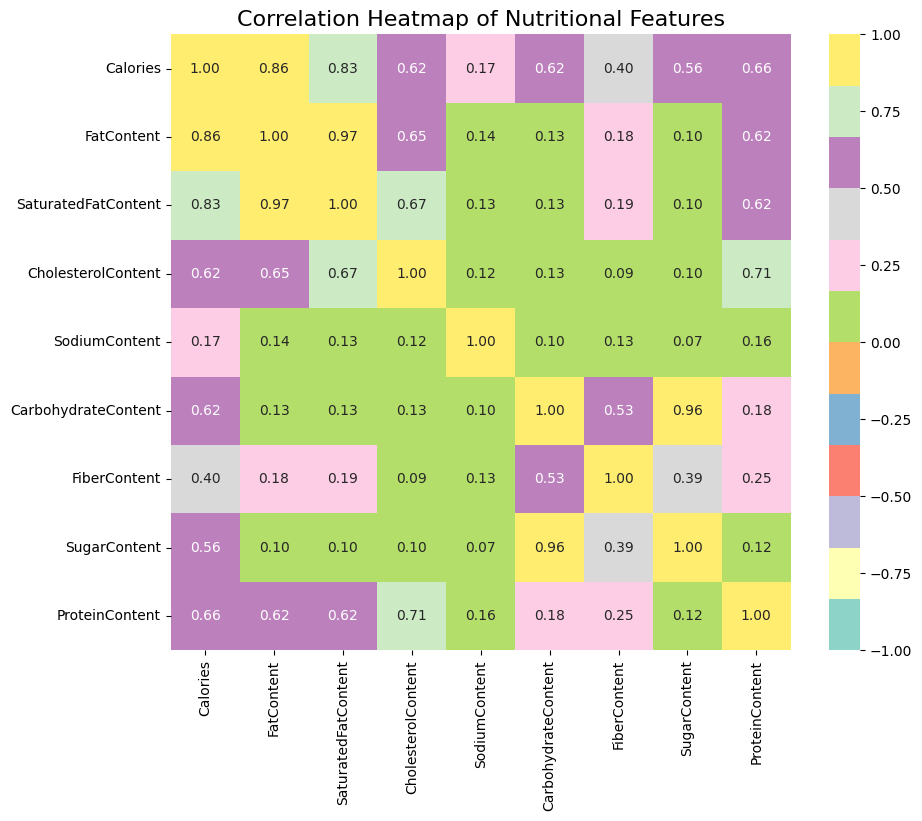

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
features=['Calories','FatContent','SaturatedFatContent','CholesterolContent','SodiumContent','CarbohydrateContent','FiberContent','SugarContent','ProteinContent']
corr = df[features].corr()
plt.figure(figsize=(10, 8))  # Set the figure size for the heatmap
sns.heatmap(corr, annot=True, cmap='Set3', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Nutritional Features', fontsize=16)  # Set the title of the heatmap
plt.show()  # Display the heatmap

## 1) Preprocessing of data

In [11]:
def _safe_list(x):
    """
    Convert various list-like formats into a Python list.
    Handles:
    - actual Python lists
    - stringified lists
    - JSON lists
    - R-style c("a","b")
    - comma-separated strings
    """

    # Missing value
    if pd.isna(x):
        return []

    # Already a list
    if isinstance(x, list):
        return x

    s = str(x).strip()

    if not s:
        return []

    # Try Python literal list
    try:
        val = ast.literal_eval(s)
        if isinstance(val, list):
            return val
    except Exception:
        pass

    # Try JSON list
    try:
        val = json.loads(s)
        if isinstance(val, list):
            return val
    except Exception:
        pass

    # Handle R-style c("a","b")
    if s.startswith("c(") and s.endswith(")"):
        inner = s[2:-1]

        parts = re.findall(r'"([^"]+)"|\'([^\']+)\'', inner)
        values = [a or b for a, b in parts if (a or b)]

        if values:
            return values

    # Handle comma-separated values
    if "," in s:
        return [item.strip() for item in s.split(",") if item.strip()]

    # Fallback: single element
    return [s]

In [12]:
def clean_ingredient(token: str) -> str:
    if not isinstance(token, str):
        return ""

    t = token.lower().strip()
    t = re.sub(r"\d+", " ", t)
    t = re.sub(r"[^a-z\s]", " ", t)

    stop_words = {
        "fresh", "chopped", "ground", "optional", "to", "taste",
        "small", "large", "cup", "cups", "tbsp", "tsp", "oz",
        "lb", "lbs", "tablespoon", "tablespoons", "teaspoon",
        "teaspoons", "package", "packages", "can", "cans",
        "sliced", "diced", "minced", "boneless", "skinless"
    }

    words = [w for w in t.split() if w not in stop_words]
    return " ".join(words).strip()

In [13]:
def parse_instructions(value):
    """
    Convert recipe instructions into a clean list of steps.
    Handles:
    - missing values
    - existing Python lists
    - stringified Python lists
    - JSON lists
    - R-style c("step1","step2")
    - plain text split into sentences
    """
    if pd.isna(value):
        return []

    if isinstance(value, list):
        return [str(x).strip() for x in value if str(x).strip()]

    text = str(value).strip()
    if not text:
        return []

    # Python-style list string
    try:
        parsed = ast.literal_eval(text)
        if isinstance(parsed, list):
            return [str(x).strip() for x in parsed if str(x).strip()]
    except Exception:
        pass

    # JSON list string
    try:
        parsed = json.loads(text)
        if isinstance(parsed, list):
            return [str(x).strip() for x in parsed if str(x).strip()]
    except Exception:
        pass

    # R-style c("...", "...")
    if text.startswith("c(") and text.endswith(")"):
        inner = text[2:-1]
        parts = re.findall(r'"([^"]+)"|\'([^\']+)\'', inner)
        values = [(a or b).strip() for a, b in parts if (a or b)]
        if values:
            return values

    # Fallback: split plain text into sentences
    parts = [p.strip() for p in re.split(r"\.\s+|\n+", text) if p.strip()]
    return parts if parts else [text]

In [14]:
def parse_time_to_minutes(x):
    if pd.isna(x):
        return None

    s = str(x).strip()
    match = re.match(r"^PT(?:(\d+)H)?(?:(\d+)M)?$", s)
    if match:
        h = int(match.group(1) or 0)
        m = int(match.group(2) or 0)
        return h * 60 + m

    try:
        return float(s)
    except Exception:
        return None

In [15]:
def calculate_bmi(weight_kg, height_cm):
    height_m = height_cm / 100
    return weight_kg / (height_m ** 2)


def calculate_bmr(weight_kg, height_cm, age, sex):
    sex = str(sex).lower()
    if sex == "male":
        return (9.99 * weight_kg) + (6.25 * height_cm) - (4.92 * age) + 5
    return (9.99 * weight_kg) + (6.25 * height_cm) - (4.92 * age) - 161


def calculate_tdee(bmr, activity_level):
    activity_multipliers = {
        "sedentary": 1.2,
        "lightly_active": 1.375,
        "moderate": 1.55,
        "very_active": 1.725,
        "extra_active": 1.9,
    }
    return bmr * activity_multipliers.get(activity_level, 1.2)


def adjust_calories(tdee, goal, sex):
    if goal == "weight_loss":
        target = tdee * 0.8
        floor = 1500 if str(sex).lower() == "male" else 1200
        return max(target, floor)
    if goal == "weight_gain":
        return tdee * 1.1
    return tdee


def calculate_macros(calories, goal, weight_kg):
    if goal == "weight_loss":
        protein = 1.8 * weight_kg
        fat = 0.8 * weight_kg
    elif goal == "weight_gain":
        protein = 1.6 * weight_kg
        fat = 0.9 * weight_kg
    else:
        protein = 1.6 * weight_kg
        fat = 0.8 * weight_kg

    carbs = max((calories - protein * 4 - fat * 9) / 4, 0)
    return protein, fat, carbs


def build_user_targets(user_profile, meals_per_day=3):
    bmi = calculate_bmi(user_profile["weight"], user_profile["height"])
    bmr = calculate_bmr(
        user_profile["weight"],
        user_profile["height"],
        user_profile["age"],
        user_profile["sex"],
    )
    tdee = calculate_tdee(bmr, user_profile["activity_level"])
    target_calories = adjust_calories(tdee, user_profile["goal"], user_profile["sex"])
    protein_target, fat_target, carb_target = calculate_macros(
        target_calories,
        user_profile["goal"],
        user_profile["weight"],
    )

    return {
        "bmi": bmi,
        "bmr": bmr,
        "tdee": tdee,
        "target_calories": target_calories,
        "target_protein": protein_target,
        "target_fat": fat_target,
        "target_carbs": carb_target,
        "meal_calories": target_calories / meals_per_day,
        "meal_protein": protein_target / meals_per_day,
        "meal_fat": fat_target / meals_per_day,
        "meal_carbs": carb_target / meals_per_day,
    }


In [16]:
def add_weight_loss_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    nutrition_cols = ["calories", "protein", "fat", "carbs", "sugar", "fiber"]
    for col in nutrition_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["name", "calories", "protein", "fat", "carbs", "cook_time"])
    df = df[df["ingredients_text"].fillna("").str.strip().astype(bool)]

    df = df[
        (df["calories"] > 0) & (df["calories"] <= 2000) &
        (df["protein"] >= 0) & (df["protein"] <= 150) &
        (df["fat"] >= 0) & (df["fat"] <= 150) &
        (df["carbs"] >= 0) & (df["carbs"] <= 300) &
        (df["sugar"] >= 0) & (df["sugar"] <= 120) &
        (df["fiber"] >= 0) & (df["fiber"] <= 60) &
        (df["cook_time"] >= 0) & (df["cook_time"] <= 300)
    ].copy()

    df["protein_ratio"] = df["protein"] / (df["calories"] + EPS)
    df["fiber_ratio"] = df["fiber"] / (df["calories"] + EPS)
    df["sugar_ratio"] = df["sugar"] / (df["calories"] + EPS)
    df["fat_ratio"] = df["fat"] / (df["calories"] + EPS)
    df["carb_ratio"] = df["carbs"] / (df["calories"] + EPS)

    df["protein_per_100kcal"] = df["protein"] / (df["calories"] / 100 + EPS)
    df["fiber_per_100kcal"] = df["fiber"] / (df["calories"] / 100 + EPS)
    df["sugar_per_100kcal"] = df["sugar"] / (df["calories"] / 100 + EPS)
    df["fat_per_100kcal"] = df["fat"] / (df["calories"] / 100 + EPS)
    df["carbs_per_100kcal"] = df["carbs"] / (df["calories"] / 100 + EPS)

    df["calories_per_protein"] = df["calories"] / (df["protein"] + EPS)
    df["fiber_plus_protein"] = df["fiber"] + df["protein"]
    df["sugar_to_fiber"] = df["sugar"] / (df["fiber"] + 1.0)

    return df


def add_weight_loss_score(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["weight_loss_score"] = (
        3.0 * df["protein_per_100kcal"]
        + 2.5 * df["fiber_per_100kcal"]
        - 2.0 * df["sugar_per_100kcal"]
        - 0.003 * df["calories"]
    )
    return df


def add_weight_loss_label(df: pd.DataFrame, quantile: float = 0.6) -> pd.DataFrame:
    df = df.copy()
    threshold = df["weight_loss_score"].quantile(quantile)
    df["weight_loss_friendly"] = (df["weight_loss_score"] >= threshold).astype(int)
    return df

In [17]:
def infer_food_tags(row):
    text_parts = []
    for col in ["name", "ingredients_text", "RecipeCategory", "Keywords"]:
        value = row.get(col, "")
        if isinstance(value, list):
            value = " ".join(map(str, value))
        if pd.notna(value):
            text_parts.append(str(value).lower())
    text = " ".join(text_parts)

    ingredients = set(row.get("ingredients_clean", []))
    tags = set()

    chicken_terms = {"chicken", "chicken breast", "chicken thigh", "ground chicken"}
    seafood_terms = {"fish", "salmon", "shrimp", "tuna", "cod", "tilapia", "prawn", "sardine"}
    meat_terms = {"beef", "lamb", "pork", "steak", "bacon", "sausage", "meatball", "turkey"}
    animal_terms = chicken_terms | seafood_terms | meat_terms | {"egg", "milk", "butter", "cheese", "yogurt", "cream", "honey"}
    vegetarian_blockers = chicken_terms | seafood_terms | meat_terms | {"gelatin"}
    vegan_blockers = vegetarian_blockers | {"egg", "milk", "butter", "cheese", "yogurt", "cream", "honey", "mayonnaise"}

    if any(term in text for term in chicken_terms) or ingredients.intersection(chicken_terms):
        tags.add("chicken")
    if any(term in text for term in seafood_terms) or ingredients.intersection(seafood_terms):
        tags.add("seafood")
    if any(term in text for term in meat_terms) or ingredients.intersection(meat_terms):
        tags.add("meat")

    if not any(term in text for term in vegetarian_blockers) and not ingredients.intersection(vegetarian_blockers):
        tags.add("vegetarian")
    if not any(term in text for term in vegan_blockers) and not ingredients.intersection(vegan_blockers):
        tags.add("vegan")

    if "vegan" in text:
        tags.add("vegan")
        tags.add("vegetarian")
    if "vegetarian" in text:
        tags.add("vegetarian")

    if not tags:
        tags.add("other")

    return sorted(tags)


def preferred_food_match(recipe_tags, preferred_food_types):
    if not preferred_food_types:
        return True
    recipe_tags = set(recipe_tags or [])
    preferred = {str(x).strip().lower() for x in preferred_food_types if str(x).strip()}
    return bool(recipe_tags.intersection(preferred))

In [18]:
def load_and_process_recipe_csv(path_csv: str) -> pd.DataFrame:
    df = pd.read_csv(path_csv)

    required_cols = [
        "RecipeId", "Name", "RecipeIngredientParts", "RecipeInstructions", "TotalTime",
        "Calories", "FatContent", "CarbohydrateContent",
        "FiberContent", "SugarContent", "ProteinContent"
    ]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df["ingredients_list"] = df["RecipeIngredientParts"].apply(_safe_list)
    df["ingredients_clean"] = df["ingredients_list"].apply(
        lambda lst: [clean_ingredient(x) for x in lst if clean_ingredient(x)]
    )
    df["ingredients_text"] = df["ingredients_clean"].apply(
        lambda x: " ".join(x) if isinstance(x, list) else ""
    )
    df["instructions_list"] = df["RecipeInstructions"].apply(parse_instructions)

    numeric_cols = [
        "Calories", "FatContent", "CarbohydrateContent",
        "FiberContent", "SugarContent", "ProteinContent"
    ]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["cook_time"] = df["TotalTime"].apply(parse_time_to_minutes)

    df = df.rename(columns={
        "RecipeId": "recipe_id",
        "Name": "name",
        "Calories": "calories",
        "FatContent": "fat",
        "CarbohydrateContent": "carbs",
        "FiberContent": "fiber",
        "SugarContent": "sugar",
        "ProteinContent": "protein",
    })

    keep_cols = [
        "recipe_id", "name", "ingredients_clean", "ingredients_text",
        "instructions_list", "cook_time", "calories", "protein",
        "fat", "carbs", "sugar", "fiber", "RecipeCategory", "Keywords"
    ]
    df = df[keep_cols].copy()

    df = add_weight_loss_features(df)
    df = add_weight_loss_score(df)
    df = add_weight_loss_label(df, quantile=0.6)
    df["food_tags"] = df.apply(infer_food_tags, axis=1)

    df = df.drop_duplicates(subset=["name", "ingredients_text"]).reset_index(drop=True)
    return df


In [19]:
df = load_and_process_recipe_csv(RAW_DATA_PATH)
df.head()

,recipe_id,name,ingredients_clean,ingredients_text,instructions_list,cook_time,calories,protein,fat,carbs,...,fiber_per_100kcal,sugar_per_100kcal,fat_per_100kcal,carbs_per_100kcal,calories_per_protein,fiber_plus_protein,sugar_to_fiber,weight_loss_score,weight_loss_friendly,food_tags
0,39,Biryani,"[saffron, milk, hot green chili peppers, onion...",saffron milk hot green chili peppers onions ga...,[Soak saffron in warm milk for 5 minutes and p...,265.0,1110.7,63.4,58.8,84.4,...,0.810300,1.836679,5.293958,7.598811,17.518927,72.4,2.040000,12.144625,1,[chicken]
1,40,Best Lemonade,"[sugar, lemons rind of, lemon zest of, water, ...",sugar lemons rind of lemon zest of water lemon...,"[Into a 1 quart Jar with tight fitting lid, pu...",35.0,311.1,0.3,0.2,81.5,...,0.128576,24.815164,0.064288,26.197356,1036.996543,0.7,55.142857,-49.952892,0,"[vegan, vegetarian]"
2,42,Cabbage Soup,"[plain tomato juice, cabbage, onion, carrots, ...",plain tomato juice cabbage onion carrots celery,"[Mix everything together and bring to a boil.,...",50.0,103.6,4.3,0.4,25.1,...,4.633200,17.084926,0.386100,24.227776,24.093018,9.1,3.051724,-10.445925,0,"[vegan, vegetarian]"
3,43,Best Blackbottom Pie,"[graham cracker crumbs, sugar, butter, sugar, ...",graham cracker crumbs sugar butter sugar corns...,"[Graham Cracker Crust: In small bowl, combine ...",140.0,437.9,7.0,19.3,58.0,...,0.411053,9.705410,4.407398,13.245030,62.557134,8.8,15.178571,-14.901274,0,[other]
4,44,Warm Chicken A La King,"[chicken, butter, flour, milk, celery, button ...",chicken butter flour milk celery button mushro...,"[Melt 1 1/2 ozs butter, add the flour and cook...",38.0,895.5,45.3,66.8,29.1,...,0.346175,0.558347,7.459519,3.249581,19.768211,48.4,1.219512,12.238121,1,[chicken]


In [20]:
df.info

<bound method DataFrame.info of         recipe_id                                      name  \
0              39                                   Biryani   
1              40                             Best Lemonade   
2              42                              Cabbage Soup   
3              43                      Best Blackbottom Pie   
4              44                    Warm Chicken A La King   
...           ...                                       ...   
471587     541378                 Meg's Pumpkin Spice Bread   
471588     541379            Meg's Fresh Ginger Gingerbread   
471589     541381                     Kirshwasser Ice Cream   
471590     541382  Quick & Easy Asian Cucumber Salmon Rolls   
471591     541383                   Spicy Baked Scotch Eggs   

                                        ingredients_clean  \
0       [saffron, milk, hot green chili peppers, onion...   
1       [sugar, lemons rind of, lemon zest of, water, ...   
2       [plain tomato juice,

## 2) Raw data preprocess, save parquet

In [24]:
df.to_parquet(PROCESSED_DATA_PATH, index=False)

print("Saved:", PROCESSED_DATA_PATH)
print("Rows:", len(df))
df[["name", "ingredients_clean", "ingredients_text", "instructions_list"]].head(3)


Saved: processed_data/dataset.parquet
Rows: 471592


,name,ingredients_clean,ingredients_text,instructions_list
0,Biryani,"[saffron, milk, hot green chili peppers, onion...",saffron milk hot green chili peppers onions ga...,[Soak saffron in warm milk for 5 minutes and p...
1,Best Lemonade,"[sugar, lemons rind of, lemon zest of, water, ...",sugar lemons rind of lemon zest of water lemon...,"[Into a 1 quart Jar with tight fitting lid, pu..."
2,Cabbage Soup,"[plain tomato juice, cabbage, onion, carrots, ...",plain tomato juice cabbage onion carrots celery,"[Mix everything together and bring to a boil.,..."


## 3) Quick dataset checks

In [25]:
print(df.columns.tolist())
print("Available food tags example:")
print(df["food_tags"].explode().value_counts().head(10))

df[["calories", "protein", "fat", "carbs", "sugar", "fiber", "cook_time"]].describe().round(2)


['recipe_id', 'name', 'ingredients_clean', 'ingredients_text', 'instructions_list', 'cook_time', 'calories', 'protein', 'fat', 'carbs', 'sugar', 'fiber', 'RecipeCategory', 'Keywords', 'protein_ratio', 'fiber_ratio', 'sugar_ratio', 'fat_ratio', 'carb_ratio', 'protein_per_100kcal', 'fiber_per_100kcal', 'sugar_per_100kcal', 'fat_per_100kcal', 'carbs_per_100kcal', 'calories_per_protein', 'fiber_plus_protein', 'sugar_to_fiber', 'weight_loss_score', 'weight_loss_friendly', 'food_tags']
Available food tags example:
food_tags
vegetarian    299629
meat           89582
vegan          82984
chicken        68227
seafood        28171
other           4144
Name: count, dtype: int64


,calories,protein,fat,carbs,sugar,fiber,cook_time
count,471592.00,471592.00,471592.00,471592.00,471592.00,471592.00,471592.00
mean,368.96,15.28,18.86,34.98,12.82,3.27,50.21
std,280.95,16.77,19.57,31.84,17.36,3.97,46.86
min,0.10,0.00,0.00,0.00,0.00,0.00,1.00
25%,169.40,3.40,5.60,12.50,2.40,0.80,20.00
50%,302.30,8.60,13.30,27.10,6.00,2.10,38.00
75%,488.80,23.10,25.50,47.70,15.80,4.20,60.00
max,2000.00,149.80,150.00,300.00,120.00,60.00,300.00


## 4) Weight-loss target creation

In [26]:
df["weight_loss_friendly"].value_counts(normalize=True).rename("share")

weight_loss_friendly
0    0.599794
1    0.400206
Name: share, dtype: float64

## 5) Train weight-loss classifier (Logistic Regression)

In [27]:
WEIGHT_LOSS_MODEL_PATH = Path("models/weight_loss_pipeline.joblib")
WEIGHT_LOSS_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

WEIGHT_LOSS_FEATURES = [
    #"protein_ratio",
    #"fiber_ratio",
    #"sugar_ratio",
    "fat_ratio",
    "carb_ratio",
    #"protein_per_100kcal",
    #"fiber_per_100kcal",
    #"sugar_per_100kcal",
    #"fat_per_100kcal",
    #"carbs_per_100kcal",
    "calories_per_protein",
    "fiber_plus_protein",
    "sugar_to_fiber",
]


X = df[WEIGHT_LOSS_FEATURES]
y = df["weight_loss_friendly"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

weight_loss_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=3000, class_weight="balanced"))
])

weight_loss_pipeline.fit(X_train, y_train)

y_pred = weight_loss_pipeline.predict(X_test)
y_prob = weight_loss_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

joblib.dump(weight_loss_pipeline, WEIGHT_LOSS_MODEL_PATH)
print("Saved:", WEIGHT_LOSS_MODEL_PATH)

              precision    recall  f1-score   support

           0       0.93      0.87      0.90     56572
           1       0.82      0.90      0.86     37747

    accuracy                           0.88     94319
   macro avg       0.87      0.88      0.88     94319
weighted avg       0.88      0.88      0.88     94319

ROC-AUC: 0.9423320514847395
Saved: models/weight_loss_pipeline.joblib


## 6) Learned coefficients / explainability

In [29]:
clf = weight_loss_pipeline.named_steps["clf"]

coef_df = pd.DataFrame({
    "feature": WEIGHT_LOSS_FEATURES,
    "coefficient": clf.coef_[0]
}).sort_values("coefficient")

print("Top negative indicators for weight loss:")
coef_df.head(6)


Top negative indicators for weight loss:


,feature,coefficient
2,calories_per_protein,-14.939821
4,sugar_to_fiber,-3.934240
1,carb_ratio,-2.892727
0,fat_ratio,-2.587576
3,fiber_plus_protein,0.921199


In [30]:
print("Top positive indicators for weight loss:")
coef_df.tail(6)

Top positive indicators for weight loss:


,feature,coefficient
2,calories_per_protein,-14.939821
4,sugar_to_fiber,-3.934240
1,carb_ratio,-2.892727
0,fat_ratio,-2.587576
3,fiber_plus_protein,0.921199


## 7) Optional regression: predict cook time

In [31]:
df["num_ingredients"] = df["ingredients_clean"].apply(len)
df["num_steps"] = df["instructions_list"].apply(len)

df["complexity"] = df["num_ingredients"] + df["num_steps"]

COOKING_TIME_FEATURES = [
    "num_ingredients",
    "num_steps",
    "complexity",
    "protein",
    "fat",
    "carbs"
]

X_reg = df[COOKING_TIME_FEATURES]
y_reg = df["cook_time"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

from sklearn.ensemble import RandomForestRegressor

reg_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    max_depth=12
)

reg_model.fit(Xr_train, yr_train)

yr_pred = reg_model.predict(Xr_test)

from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", round(mean_absolute_error(yr_test, yr_pred), 2))
print("R2 :", round(r2_score(yr_test, yr_pred), 3))


MAE: 28.13
R2 : 0.127


## 6) Healthy / unhealthy target creation

In [32]:
def compute_health_label(df):

    df["health_score"] = (
        4 * df["protein"] +
        3 * df["fiber"] -
        2 * df["sugar"] -
        0.02 * df["calories"]
    )

    threshold = df["health_score"].quantile(0.6)

    df["healthy"] = (df["health_score"] >= threshold).astype(int)

    return df

In [33]:
df = compute_health_label(df)
df["healthy"].value_counts(normalize=True)

healthy
0    0.599997
1    0.400003
Name: proportion, dtype: float64

## 5) Train healthy classifier (Logistic Regression)

In [34]:

HEALTH_FEATURES = [
    "calories", "protein", "fat", "carbs", "sugar", "fiber",
    "protein_ratio", "fiber_ratio", "sugar_ratio", "calories_per_protein",
]

X = df[HEALTH_FEATURES]
y = df["healthy"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

health_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

health_pipeline.fit(X_train, y_train)

y_pred = health_pipeline.predict(X_test)
y_prob = health_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

joblib.dump(health_pipeline, HEALTH_MODEL_PATH)
print("Saved:", HEALTH_MODEL_PATH)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56591
           1       1.00      1.00      1.00     37728

    accuracy                           1.00     94319
   macro avg       1.00      1.00      1.00     94319
weighted avg       1.00      1.00      1.00     94319

ROC-AUC: 0.9999966520929482
Saved: models/healthy_classifier.joblib


## 6) Learned coefficients / explainability

In [35]:

clf = health_pipeline.named_steps["clf"]

coef_df = pd.DataFrame({
    "feature": HEALTH_FEATURES,
    "coefficient": clf.coef_[0]
}).sort_values("coefficient")

print("Top unhealthy indicators:")
coef_df.head(5)


Top unhealthy indicators:


,feature,coefficient
4,sugar,-26.935923
2,fat,-1.853788
3,carbs,-1.469305
0,calories,-1.101836
9,calories_per_protein,-0.299759


In [ ]:

print("Top healthy indicators:")
coef_df.tail(5)


Top healthy indicators:


,feature,coefficient
7,fiber_ratio,-0.166473
8,sugar_ratio,0.169866
6,protein_ratio,0.232769
5,fiber,9.574350
1,protein,50.752487


## 7) Optional regression: predict cook time

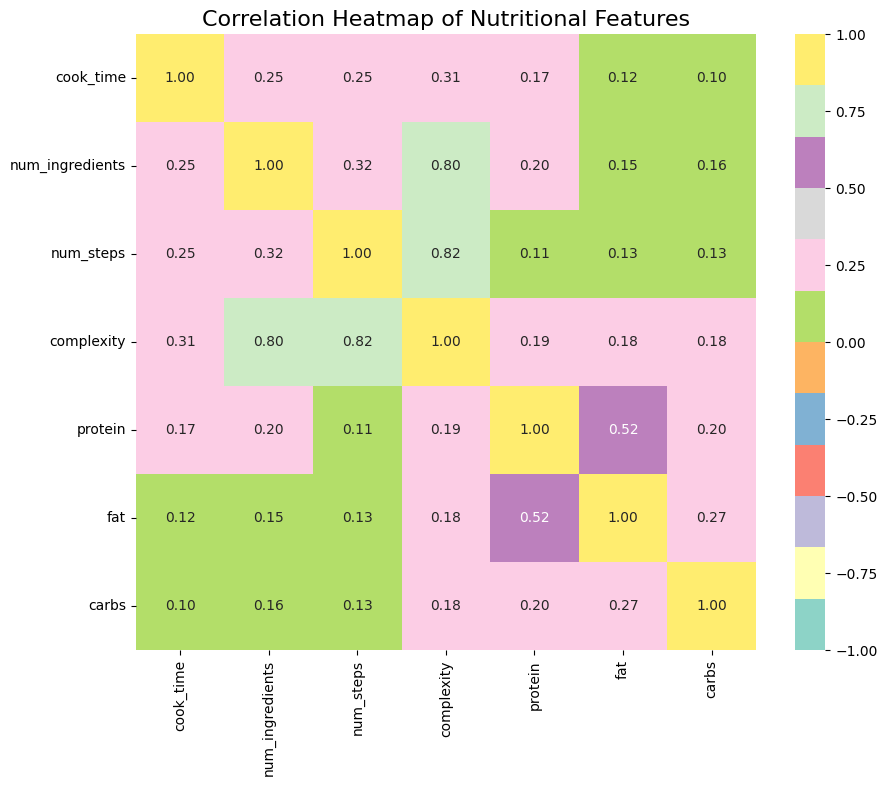

In [36]:
df["num_ingredients"] = df["ingredients_clean"].apply(len)
df["num_steps"] = df["instructions_list"].apply(len)

df["complexity"] = df["num_ingredients"] + df["num_steps"]


corr = df[["cook_time", "num_ingredients", "num_steps", "complexity", "protein", "fat", "carbs"]].corr()
plt.figure(figsize=(10, 8))  # Set the figure size for the heatmap
sns.heatmap(corr, annot=True, cmap='Set3', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Nutritional Features', fontsize=16)  # Set the title of the heatmap
plt.show()  # Display the heatmap

In [37]:
df["num_ingredients"] = df["ingredients_clean"].apply(len)
df["num_steps"] = df["instructions_list"].apply(len)

df["complexity"] = df["num_ingredients"] + df["num_steps"]

COOKING_TIME_FEATURES = [
    "num_ingredients",
    "num_steps",
    "complexity",
    "protein",
    "fat",
    "carbs"
]

X_reg = df[COOKING_TIME_FEATURES]
y_reg = df["cook_time"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

from sklearn.ensemble import RandomForestRegressor

reg_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    max_depth=12
)

reg_model.fit(Xr_train, yr_train)

yr_pred = reg_model.predict(Xr_test)

from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", round(mean_absolute_error(yr_test, yr_pred), 2))
print("R2 :", round(r2_score(yr_test, yr_pred), 3))

MAE: 28.13
R2 : 0.127


## 8) Train KNN recommender on macro targets

In [38]:
macro_X = df[["protein", "fat", "carbs"]].copy()

macro_scaler = StandardScaler()
macro_X_scaled = macro_scaler.fit_transform(macro_X)

knn_model = NearestNeighbors(n_neighbors=30, metric="euclidean")
knn_model.fit(macro_X_scaled)

joblib.dump({"model": knn_model, "scaler": macro_scaler}, KNN_MODEL_PATH)
print("Saved:", KNN_MODEL_PATH)


Saved: models/knn_macro.joblib


## 9) Train TF-IDF ingredient matching

In [39]:
tfidf_df = df[df["ingredients_text"].fillna("").str.strip().astype(bool)].copy()

vectorizer = TfidfVectorizer(lowercase=True)
ingredient_matrix = vectorizer.fit_transform(tfidf_df["ingredients_text"])

joblib.dump(vectorizer, TFIDF_PATH)
save_npz(INGREDIENT_MATRIX_PATH, ingredient_matrix)

print("Saved:", TFIDF_PATH)
print("Saved:", INGREDIENT_MATRIX_PATH)
print("Vocabulary size:", len(vectorizer.vocabulary_))


Saved: models/tfidf_vectorizer.joblib
Saved: models/ingredient_matrix.npz
Vocabulary size: 2912


## 10) Recommendation helper functions

In [40]:
def knn_candidates(df, protein, fat, carbs, n_neighbors=30):
    user_vec = pd.DataFrame([{
        "protein": protein,
        "fat": fat,
        "carbs": carbs
    }])
    user_scaled = macro_scaler.transform(user_vec)
    distances, indices = knn_model.kneighbors(user_scaled, n_neighbors=n_neighbors)

    candidates = df.iloc[indices[0]].copy()
    candidates["macro_distance"] = distances[0]
    candidates["macro_score"] = 1 / (1 + candidates["macro_distance"])
    return candidates


def ingredient_similarity(candidates, user_ingredients):
    candidates = candidates.copy()

    cleaned_user_ingredients = []
    for item in (user_ingredients or []):
        cleaned = clean_ingredient(str(item))
        if cleaned:
            cleaned_user_ingredients.append(cleaned)

    cleaned_user_ingredients = sorted(set(cleaned_user_ingredients))

    if not cleaned_user_ingredients:
        candidates["ingredient_overlap_score"] = 0.0
        candidates["ingredient_tfidf_score"] = 0.0
        candidates["ingredient_score"] = 0.0
        candidates["matched_ingredients"] = [[] for _ in range(len(candidates))]
        candidates["missing_ingredients"] = candidates["ingredients_clean"].apply(
            lambda x: x[:10] if isinstance(x, list) else []
        )
        return candidates

    user_set = set(cleaned_user_ingredients)
    user_text = " ".join(cleaned_user_ingredients)
    user_vec = vectorizer.transform([user_text])
    sims = cosine_similarity(user_vec, ingredient_matrix).flatten()
    sim_map = pd.Series(sims, index=tfidf_df.index)

    def _matched(recipe_ingredients):
        recipe_set = {x for x in recipe_ingredients if x}
        return sorted(recipe_set.intersection(user_set))

    def _missing(recipe_ingredients):
        recipe_set = {x for x in recipe_ingredients if x}
        return sorted(recipe_set.difference(user_set))

    def _overlap(recipe_ingredients):
        recipe_set = {x for x in recipe_ingredients if x}
        if not recipe_set:
            return 0.0
        return len(recipe_set.intersection(user_set)) / len(recipe_set)

    candidates["matched_ingredients"] = candidates["ingredients_clean"].apply(_matched)
    candidates["missing_ingredients"] = candidates["ingredients_clean"].apply(_missing)
    candidates["ingredient_overlap_score"] = candidates["ingredients_clean"].apply(_overlap)
    candidates["ingredient_tfidf_score"] = candidates.index.map(sim_map).fillna(0.0)
    candidates["ingredient_score"] = (
        0.7 * candidates["ingredient_overlap_score"] +
        0.3 * candidates["ingredient_tfidf_score"]
    )
    return candidates


def filter_by_preferences(candidates, preferred_food_types=None, max_missing_ingredients=None):
    filtered = candidates.copy()

    if preferred_food_types:
        filtered = filtered[
            filtered["food_tags"].apply(lambda tags: preferred_food_match(tags, preferred_food_types))
        ].copy()

    if max_missing_ingredients is not None and "missing_ingredients" in filtered.columns:
        filtered = filtered[
            filtered["missing_ingredients"].apply(len) <= max_missing_ingredients
        ].copy()

    return filtered


def add_weight_loss_probability(candidates):
    candidates = candidates.copy()
    candidates["weight_loss_prob"] = weight_loss_pipeline.predict_proba(
        candidates[WEIGHT_LOSS_FEATURES]
    )[:, 1]
    return candidates


def final_rank(candidates):
    candidates = candidates.copy()
    candidates["final_score"] = (
        0.5 * candidates["macro_score"] +
        0.3 * candidates["ingredient_score"] +
        0.2 * candidates["weight_loss_prob"]
    )
    return candidates.sort_values("final_score", ascending=False)


def recommend_recipes(protein, fat, carbs, user_ingredients=None, preferred_food_types=None,
                      n_results=5, n_candidates=50, max_missing_ingredients=None):
    candidates = knn_candidates(df, protein, fat, carbs, n_neighbors=n_candidates)
    candidates = ingredient_similarity(candidates, user_ingredients)
    candidates = filter_by_preferences(
        candidates,
        preferred_food_types=preferred_food_types,
        max_missing_ingredients=max_missing_ingredients,
    )

    if candidates.empty:
        return pd.DataFrame()

    candidates = add_weight_loss_probability(candidates)
    candidates = final_rank(candidates)

    cols = [
        "name", "calories", "protein", "fat", "carbs", "fiber", "sugar", "cook_time",
        "food_tags", "macro_score", "ingredient_overlap_score", "ingredient_tfidf_score",
        "ingredient_score", "weight_loss_prob", "final_score",
        "matched_ingredients", "missing_ingredients",
        "ingredients_clean", "instructions_list"
    ]
    return candidates[cols].head(n_results)

## 11) User profile inputs and meal targets

This cell is the app-style input layer. Change the values to simulate a different user, their available ingredients, and their preferred food type.

In [41]:
user_profile = {
    "weight": 75,
    "height": 178,
    "age": 30,
    "sex": "male",
    "activity_level": "moderate",
    "goal": "weight_loss",
    "available_ingredients": ["chicken", "rice", "onion", "garlic", "yogurt", "broccoli"],
    "preferred_food_types": ["chicken"],  # examples: meat, chicken, seafood, vegetarian, vegan
}

user_targets = build_user_targets(user_profile, meals_per_day=3)

print("BMI:", round(user_targets["bmi"], 2))
print("BMR:", round(user_targets["bmr"]))
print("TDEE:", round(user_targets["tdee"]))
print("Daily calories:", round(user_targets["target_calories"]))
print("Daily macros -> protein:", round(user_targets["target_protein"]),
      "fat:", round(user_targets["target_fat"]),
      "carbs:", round(user_targets["target_carbs"]))
print("Per-meal macros -> protein:", round(user_targets["meal_protein"]),
      "fat:", round(user_targets["meal_fat"]),
      "carbs:", round(user_targets["meal_carbs"]))

BMI: 23.67
BMR: 1719
TDEE: 2665
Daily calories: 2132
Daily macros -> protein: 135 fat: 60 carbs: 263
Per-meal macros -> protein: 45 fat: 20 carbs: 88


## 12) Test the recommender with user profile, ingredients, and food preference

In [42]:

recs = recommend_recipes(
    protein=user_targets["meal_protein"],
    fat=user_targets["meal_fat"],
    carbs=user_targets["meal_carbs"],
    user_ingredients=user_profile["available_ingredients"],
    preferred_food_types=user_profile["preferred_food_types"],
    max_missing_ingredients=6,
    n_results=5,
)

if recs.empty:
    print("No recipes matched the selected food type and ingredient constraints.")
else:
    display(recs[[
        "name", "food_tags", "calories", "protein", "fat", "carbs",
        "ingredient_overlap_score", "ingredient_score",
        "weight_loss_prob", "final_score",
        "matched_ingredients", "missing_ingredients"
    ]])


,name,food_tags,calories,protein,fat,carbs,ingredient_overlap_score,ingredient_score,weight_loss_prob,final_score,matched_ingredients,missing_ingredients
172810,Cheesy Chicken and Rice (Easy Version),[chicken],722.7,44.0,21.3,86.0,0.142857,0.184328,0.965358,0.701617,[rice],"[cayenne, cheddar cheese, chicken breasts, cum..."
453297,Cheesy Chicken Penne (Baked!) SUPER EASY,[chicken],736.9,45.3,21.3,88.0,0.000000,0.060401,0.972763,0.680096,[],"[alfredo sauce, black pepper, chicken breasts,..."
12593,New Year's Chicken Alfredo,[chicken],767.4,46.1,18.1,91.3,0.142857,0.137481,0.984246,0.667635,[onion],"[alfredo sauce, bouillon, butter, chicken brea..."
445034,Chicken &amp; Rice,"[chicken, meat]",698.5,44.9,17.0,89.1,0.000000,0.070270,0.967181,0.645521,[],"[beef broth, chicken breasts, flour, minute rice]"
236529,Lemon Chicken With Spaghetti,[chicken],733.3,45.8,18.7,91.5,0.000000,0.025968,0.982477,0.640545,[],"[chicken breasts, lemons, olive oil, spaghetti..."


## 13) Inspect one full recipe

In [43]:
if recs.empty:
    print("Run the previous cell with a broader preference or more ingredients.")
else:
    recipe = recs.iloc[0]

    print("Recipe:", recipe["name"])
    print("Food tags:", ", ".join(recipe["food_tags"]))

    print("\nIngredients:")
    print(", ".join(recipe["ingredients_clean"][:20]))

    print("\nInstructions:")
    for i, step in enumerate(recipe["instructions_list"][:10], start=1):
        print(f"{i}. {step}")


Recipe: Cheesy Chicken and Rice (Easy Version)
Food tags: chicken

Ingredients:
rice, chicken breasts, cheddar cheese, salsa, cumin, cayenne, garlic powder

Instructions:
1. Cook rice according to package directions, but substituting salsa for half of the water.
2. Meanwhile cook chicken in chunks in a large skillet - deep if available.  If not large enough transfer it to a pot when cooked.
3. Add queso to cooked chicken.
4. Add cheddar to hot rice.
5. Combine the two mixtures.
6. Add remaining salsa, to taste.
7. Season with cumin, cayenne, and garlic powder.
8. Some great add-ins to try are black beans, corn, diced tomatoes, or a jalapeno. They work best cooked with the chicken.


## 13) Next step

If everything looks good here, run the app from the project root:

```bash
streamlit run app/app.py
```
